In [1]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [4]:
df = pd.read_csv(r"C:\Users\nagav\OneDrive\Desktop\heart_disease_prediction\test.csv")

In [5]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [6]:
df.tail()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
269995,899995,58,1,2,120,222,0,0,172,0,1.0,1,0,7
269996,899996,58,1,4,132,289,0,0,172,0,2.8,2,0,3
269997,899997,63,1,3,108,201,1,0,158,0,0.8,1,0,3
269998,899998,59,1,4,120,274,0,2,163,0,0.5,1,0,3
269999,899999,42,1,2,120,275,0,0,173,0,0.0,1,1,3


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Age                      270000 non-null  int64  
 2   Sex                      270000 non-null  int64  
 3   Chest pain type          270000 non-null  int64  
 4   BP                       270000 non-null  int64  
 5   Cholesterol              270000 non-null  int64  
 6   FBS over 120             270000 non-null  int64  
 7   EKG results              270000 non-null  int64  
 8   Max HR                   270000 non-null  int64  
 9   Exercise angina          270000 non-null  int64  
 10  ST depression            270000 non-null  float64
 11  Slope of ST              270000 non-null  int64  
 12  Number of vessels fluro  270000 non-null  int64  
 13  Thallium                 270000 non-null  int64  
dtypes: f

In [8]:
df.shape

(270000, 14)

In [9]:
df.columns

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium'],
      dtype='object')

In [10]:
df.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.00000,270000.000000
mean,764999.500000,54.159870,0.716315,3.315107,130.555089,245.045270,0.080052,0.978493,152.783756,0.274656,0.718082,1.459356,0.45480,4.619774
std,77942.430678,8.255471,0.450787,0.851762,15.007908,33.695458,0.271374,0.998686,19.153454,0.446341,0.947417,0.546186,0.80127,1.950273
min,630000.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.00000,3.000000
25%,697499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.00000,3.000000
50%,764999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.00000,3.000000
75%,832499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.00000,7.000000
max,899999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.00000,7.000000


In [11]:
df.isnull().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
dtype: int64

In [12]:
X = df.iloc[:, :-1].values  
y = df.iloc[:, -1].values  

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# features and target
X = df.iloc[:, :-1]   # last column except
y = df.iloc[:, -1]    # last column

# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(y_train.shape)

(216000, 13)
(216000,)


In [16]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

num_classes = len(np.unique(y))

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(num_classes, activation='softmax')
])

c:\Users\nagav\.vscode\extensions\annaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model

# load model
model = load_model("model.h5")

print("Model loaded successfully")

Model loaded successfully


In [19]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 966us/step


In [20]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print("\nEvaluation Metrics")
print("------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


Evaluation Metrics
------------------
Accuracy  : 0.0000
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000


c:\Users\nagav\.vscode\extensions\annaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nagav\.vscode\extensions\annaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 1/50
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.0000e+00 - loss: -1159527621722112.0000 - val_accuracy: 0.0000e+00 - val_loss: -1394602187685888.0000
Epoch 2/50
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.0000e+00 - loss: -1634855007813632.0000 - val_accuracy: 0.0000e+00 - val_loss: -1875259091320832.0000
Epoch 3/50
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.0000e+00 - loss: -2120692849967104.0000 - val_accuracy: 0.0000e+00 - val_loss: -2366315721392128.0000
Epoch 4/50
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.0000e+00 - loss: -2617471718653952.0000 - val_accuracy: 0.0000e+00 - val_loss: -2868249758793728.0000
Epoch 5/50
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.0000e+00 - loss: -3124842379345920.0000 - val_accuracy: 0.0000e+00 - val_loss: -3380715056005120.0000
Epoch 6/50
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.0000e+00 - loss: -3643289492258816.0000 - val_accuracy: 0.0000e+00 - val_los

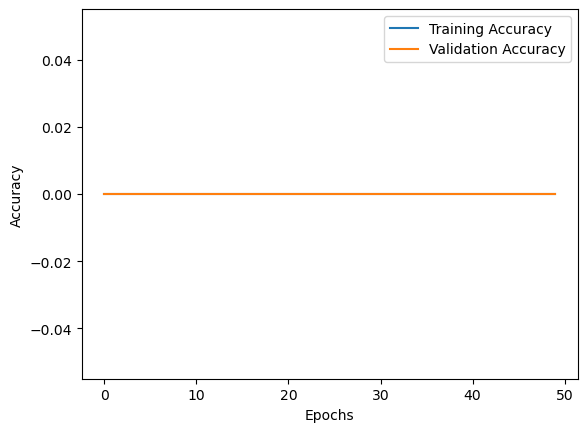

In [21]:
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam

# Model Compile
model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model Training
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# Accuracy Graph
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [22]:
from sklearn.preprocessing import StandardScaler
import pickle

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# save scaler
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)